# Experiment 2: Unsupervised SimCSE + Transfer Learning
Notebook version converted from the uploaded Python script.

This notebook keeps the same pipeline while organizing it into runnable sections for Jupyter/Colab.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

train_csv = "/content/drive/MyDrive/train.csv"
encoder_dir = "/content/drive/MyDrive/simcse_encoder"
force_pretrain = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

print(os.path.exists(train_csv))
print(os.path.exists(encoder_dir))
print(os.listdir(encoder_dir))

True
True
['config.json', 'tf_model.h5', 'tokenizer_config.json', 'vocab.txt', 'special_tokens_map.json', 'tokenizer.json']


## 1. Imports

In [6]:
!pip install -q transformers==4.49.0 tf-keras scikit-learn

import os
import json
import random
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, TFAutoModel


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset from CSV
def load_dataset(csv_path):
    df = pd.read_csv(csv_path)
    return df, None

# Split into train/validation
def make_split(df):
    text_col = "text"      # for disaster tweets dataset
    label_col = "target"

    X = df[text_col].astype(str).tolist()
    y = df[label_col].astype(int).values

    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=76,
        stratify=y
    )

    return X_tr, X_val, y_tr, y_val

## 2. Configuration and paths
In notebooks, `__file__` is not available, so paths are set relative to the current working directory.

In [8]:

# Reduce TensorFlow log noise
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 76
BASE_DIR = os.getcwd()
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

DEFAULT_TRAIN = "/content/drive/MyDrive/train.csv"
DEFAULT_ENCODER_DIR = "/content/drive/MyDrive/simcse_encoder"

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


## 3. Tokenization helpers

In [9]:

def tokenize_texts(tokenizer, texts, max_length: int):
    # Convert everything to string first so the tokenizer does not fail on missing or mixed types.
    texts = [str(x) for x in texts]
    enc = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="np"
    )

    # Keep only the keys that transformer backbones use at inference/training time.
    features = {}
    for key, value in enc.items():
        if key in ("input_ids", "attention_mask", "token_type_ids"):
            features[key] = value.astype(np.int32)
    return features


def make_unsup_dataset(features, batch_size: int, shuffle: bool = False):
    ds = tf.data.Dataset.from_tensor_slices(features)
    if shuffle:
        n = len(next(iter(features.values())))
        ds = ds.shuffle(min(n, 4096), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


## 4. SimCSE encoder and training wrapper

In [10]:

class SimCSEEncoder(tf.keras.layers.Layer):
    """
    Unsupervised SimCSE encoder:
    - backbone transformer
    - CLS embedding before pooler
    - MLP used only during contrastive training
    """

    def __init__(self, model_name: str):
        super().__init__(name="SimCSEEncoder")
        self.model_name = model_name
        self.backbone = TFAutoModel.from_pretrained(model_name)

        hidden_size = int(self.backbone.config.hidden_size)
        self.mlp = layers.Dense(hidden_size, activation="tanh", name="simcse_mlp")

    def call(self, inputs, training=False, apply_mlp=False, normalize=False):
        # If the backbone is frozen, force inference behavior inside the transformer.
        encoder_training = training if self.backbone.trainable else False
        outputs = self.backbone(**inputs, training=encoder_training)

        # Use the CLS token as the sentence representation.
        cls = outputs.last_hidden_state[:, 0, :]

        x = cls
        if apply_mlp:
            x = self.mlp(x)

        if normalize:
            x = tf.math.l2_normalize(x, axis=1)

        return x


class SimCSETrainer(tf.keras.Model):
    """
    Keras training wrapper for unsupervised SimCSE.
    """

    def __init__(self, encoder: SimCSEEncoder, temperature: float = 0.05):
        super().__init__(name="SimCSETrainer")
        self.encoder = encoder
        self.temperature = temperature
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def contrastive_loss(self, batch):
        # Two forward passes of the same batch create two different views via dropout.
        z1 = self.encoder(batch, training=True, apply_mlp=True, normalize=True)
        z2 = self.encoder(batch, training=True, apply_mlp=True, normalize=True)

        logits_12 = tf.matmul(z1, z2, transpose_b=True) / self.temperature
        logits_21 = tf.matmul(z2, z1, transpose_b=True) / self.temperature

        batch_size = tf.shape(logits_12)[0]
        labels = tf.range(batch_size)

        loss_12 = tf.keras.losses.sparse_categorical_crossentropy(
            labels, logits_12, from_logits=True
        )
        loss_21 = tf.keras.losses.sparse_categorical_crossentropy(
            labels, logits_21, from_logits=True
        )

        return tf.reduce_mean((loss_12 + loss_21) * 0.5)

    def train_step(self, data):
        batch = data[0] if isinstance(data, tuple) else data

        with tf.GradientTape() as tape:
            loss = self.contrastive_loss(batch)

        grads = tape.gradient(loss, self.encoder.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.encoder.trainable_variables))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        batch = data[0] if isinstance(data, tuple) else data
        loss = self.contrastive_loss(batch)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


## 5. Downstream classifier and evaluation

In [11]:

def build_classifier_from_encoder(encoder: SimCSEEncoder, feature_dict, lr: float = 2e-4):
    inputs = {}
    for key, value in feature_dict.items():
        seq_len = value.shape[1]
        inputs[key] = layers.Input(shape=(seq_len,), dtype=tf.int32, name=key)

    feats = encoder(inputs, apply_mlp=False, normalize=False)

    # Small dense head on top of sentence features for binary classification.
    x = layers.Dropout(0.30)(feats)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=out, name="SimCSETransferClassifier")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model


def evaluate(model, X, y, name: str):
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, zero_division=0)
    rep = classification_report(y, preds, digits=4, zero_division=0)
    cm = confusion_matrix(y, preds)

    report_path = os.path.join(RESULTS_DIR, f"exp2_{name}_report.txt")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"F1: {f1:.4f}\n")
        f.write("Confusion Matrix:\n")
        f.write(np.array2string(cm))
        f.write("\n\n")
        f.write(rep)
        f.write("\n")

    return {
        "model": name,
        "accuracy": float(acc),
        "f1": float(f1),
        "confusion_matrix": cm.tolist(),
        "preds": preds,
        "probs": probs
    }


## 6. Save / load pretrained encoder

In [12]:

def save_pretrained_encoder(encoder: SimCSEEncoder, tokenizer, save_dir: str):
    os.makedirs(save_dir, exist_ok=True)

    # Save transformer backbone and tokenizer in Hugging Face format.
    encoder.backbone.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    # Save the projection MLP separately because it is custom.
    mlp_weights = encoder.mlp.get_weights()
    if len(mlp_weights) == 2:
        np.save(os.path.join(save_dir, "simcse_mlp_kernel.npy"), mlp_weights[0])
        np.save(os.path.join(save_dir, "simcse_mlp_bias.npy"), mlp_weights[1])

    metadata = {
        "model_name_or_path": save_dir
    }
    with open(os.path.join(save_dir, "simcse_metadata.json"), "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)


def load_pretrained_encoder(save_dir: str):
    tokenizer = AutoTokenizer.from_pretrained(save_dir)
    encoder = SimCSEEncoder(model_name=save_dir)

    # Run one dummy forward pass so the custom MLP gets built before loading weights.
    dummy = tokenizer(
        ["dummy text"],
        padding="max_length",
        truncation=True,
        max_length=8,
        return_tensors="np"
    )
    dummy_features = {
        k: v.astype(np.int32)
        for k, v in dummy.items()
        if k in ("input_ids", "attention_mask", "token_type_ids")
    }

    _ = encoder(dummy_features, training=False, apply_mlp=True, normalize=False)

    kernel_path = os.path.join(save_dir, "simcse_mlp_kernel.npy")
    bias_path = os.path.join(save_dir, "simcse_mlp_bias.npy")

    if os.path.exists(kernel_path) and os.path.exists(bias_path):
        kernel = np.load(kernel_path)
        bias = np.load(bias_path)
        encoder.mlp.set_weights([kernel, bias])

    return tokenizer, encoder


## 7. Plotting helpers

In [13]:

def plot_simcse_history(history):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    plt.title("SimCSE Pretraining Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_classifier_history(history, title_prefix):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    if "accuracy" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist["accuracy"], marker="o", label="Train Accuracy")
        if "val_accuracy" in hist:
            plt.plot(epochs, hist["val_accuracy"], marker="o", label="Validation Accuracy")
        plt.title(f"{title_prefix} Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_conf_matrix(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=np.array(cm), display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_comparison(results):
    model_names = [r["model"] for r in results]
    accuracies = [r["accuracy"] for r in results]
    f1_scores = [r["f1"] for r in results]

    x = np.arange(len(model_names))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width / 2, accuracies, width, label="Accuracy")
    plt.bar(x + width / 2, f1_scores, width, label="F1 Score")
    plt.xticks(x, model_names)
    plt.ylim(0, 1.0)
    plt.title("Frozen vs Fine-tuned Performance")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 8. Main pipeline

In [14]:

def run(train_csv: str,
        model_name: str,
        max_length: int,
        simcse_epochs: int,
        clf_epochs: int,
        batch_size: int,
        temperature: float,
        simcse_lr: float,
        head_lr: float,
        ft_lr: float,
        encoder_dir: str,
        force_pretrain: bool):

    set_seed(SEED)

    # 1) Load data
    train_df, _ = load_dataset(train_csv)
    X_tr, X_val, y_tr, y_val = make_split(train_df)

    encoder_path = Path(encoder_dir)
    simcse_history_obj = None

    # 2) Load existing encoder or pretrain a new one
    if encoder_path.exists() and not force_pretrain:
        print("\n=== Found saved SimCSE encoder. Loading it... ===")
        tokenizer, encoder = load_pretrained_encoder(str(encoder_path))
    else:
        print(f"\n=== Loading tokenizer/backbone: {model_name} ===")
        tokenizer = AutoTokenizer.from_pretrained(model_name)

        X_tr_tok = tokenize_texts(tokenizer, X_tr, max_length=max_length)
        X_val_tok = tokenize_texts(tokenizer, X_val, max_length=max_length)

        unsup_train_ds = make_unsup_dataset(X_tr_tok, batch_size=batch_size, shuffle=True)
        unsup_val_ds = make_unsup_dataset(X_val_tok, batch_size=batch_size, shuffle=False)

        print("\n=== Pretraining unsupervised SimCSE ===")
        encoder = SimCSEEncoder(model_name=model_name)
        simcse = SimCSETrainer(encoder=encoder, temperature=temperature)
        simcse.compile(optimizer=tf.keras.optimizers.Adam(simcse_lr))

        simcse_history_obj = simcse.fit(
            unsup_train_ds,
            validation_data=unsup_val_ds,
            epochs=simcse_epochs,
            callbacks=[
                callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=1,
                    restore_best_weights=True
                )
            ],
            verbose=2
        )

        history_path = os.path.join(RESULTS_DIR, "exp2_simcse_history.json")
        with open(history_path, "w", encoding="utf-8") as f:
            json.dump(
                {k: [float(v) for v in vals] for k, vals in simcse_history_obj.history.items()},
                f,
                indent=2
            )

        try:
            save_pretrained_encoder(encoder, tokenizer, str(encoder_path))
            print(f"\n=== Saved pretrained encoder to: {encoder_path} ===")
        except Exception as e:
            print(f"\nWARNING: encoder trained but saving failed: {e}")

    # 3) Tokenize for downstream classification
    X_tr_tok = tokenize_texts(tokenizer, X_tr, max_length=max_length)
    X_val_tok = tokenize_texts(tokenizer, X_val, max_length=max_length)

    # 4) Compute class weights to reduce imbalance issues
    cw_vals = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=np.asarray(y_tr)
    )
    class_weight = {0: float(cw_vals[0]), 1: float(cw_vals[1])}

    # 5) Train classifier with frozen encoder
    print("\n=== Training classifier with frozen encoder ===")
    encoder.backbone.trainable = False
    encoder.mlp.trainable = False

    clf = build_classifier_from_encoder(encoder, X_tr_tok, lr=head_lr)
    frozen_history = clf.fit(
        X_tr_tok, y_tr,
        validation_data=(X_val_tok, y_val),
        epochs=clf_epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            )
        ],
        verbose=2
    )
    frozen = evaluate(clf, X_val_tok, y_val, "transfer_frozen")

    # 6) Fine-tune end-to-end
    print("\n=== Fine-tuning encoder end-to-end ===")
    encoder.backbone.trainable = True
    encoder.mlp.trainable = False

    clf.compile(
        optimizer=tf.keras.optimizers.Adam(ft_lr),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    finetuned_history = clf.fit(
        X_tr_tok, y_tr,
        validation_data=(X_val_tok, y_val),
        epochs=clf_epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            )
        ],
        verbose=2
    )
    finetuned = evaluate(clf, X_val_tok, y_val, "transfer_finetuned")

    # 7) Save summary
    results = [
        {
            "model": frozen["model"],
            "accuracy": frozen["accuracy"],
            "f1": frozen["f1"],
            "confusion_matrix": frozen["confusion_matrix"]
        },
        {
            "model": finetuned["model"],
            "accuracy": finetuned["accuracy"],
            "f1": finetuned["f1"],
            "confusion_matrix": finetuned["confusion_matrix"]
        }
    ]

    summary_path = os.path.join(RESULTS_DIR, "exp2_summary.json")
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)

    print("\nExperiment 2 summary:")
    print(json.dumps(results, indent=2))

    # 8) Show graphs
    if simcse_history_obj is not None:
        plot_simcse_history(simcse_history_obj)

    plot_classifier_history(frozen_history, "Frozen Encoder Classifier")
    plot_classifier_history(finetuned_history, "Fine-Tuned Encoder Classifier")

    plot_conf_matrix(frozen["confusion_matrix"], "Frozen Encoder Confusion Matrix")
    plot_conf_matrix(finetuned["confusion_matrix"], "Fine-Tuned Encoder Confusion Matrix")

    plot_comparison(results)

    return results


## 9. Run the experiment
Update the paths below if you are using Colab or Google Drive.

In [15]:

# Example settings for local Jupyter or Colab
train_csv = DEFAULT_TRAIN
model_name = "distilbert-base-uncased"
max_length = 64

simcse_epochs = 2
clf_epochs = 5
batch_size = 16

temperature = 0.05
simcse_lr = 3e-5
head_lr = 2e-4
ft_lr = 2e-5

encoder_dir = DEFAULT_ENCODER_DIR
force_pretrain = False



=== Found saved SimCSE encoder. Loading it... ===


All model checkpoint layers were used when initializing TFDistilBertModel.

All the layers of TFDistilBertModel were initialized from the model checkpoint at /content/drive/MyDrive/simcse_encoder.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.



=== Training classifier with frozen encoder ===
Epoch 1/5
381/381 - 36s - 96ms/step - accuracy: 0.7327 - auc: 0.8041 - loss: 0.5360 - val_accuracy: 0.7905 - val_auc: 0.8628 - val_loss: 0.4642
Epoch 2/5
381/381 - 13s - 35ms/step - accuracy: 0.7803 - auc: 0.8493 - loss: 0.4755 - val_accuracy: 0.8004 - val_auc: 0.8678 - val_loss: 0.4489
Epoch 3/5
381/381 - 14s - 36ms/step - accuracy: 0.7987 - auc: 0.8626 - loss: 0.4539 - val_accuracy: 0.7997 - val_auc: 0.8698 - val_loss: 0.4530
Epoch 4/5
381/381 - 15s - 39ms/step - accuracy: 0.8039 - auc: 0.8741 - loss: 0.4353 - val_accuracy: 0.7971 - val_auc: 0.8688 - val_loss: 0.4521

=== Fine-tuning encoder end-to-end ===
Epoch 1/5
381/381 - 46s - 120ms/step - accuracy: 0.7952 - auc: 0.8611 - loss: 0.4576 - val_accuracy: 0.8024 - val_auc: 0.8680 - val_loss: 0.4588
Epoch 2/5
381/381 - 18s - 47ms/step - accuracy: 0.7998 - auc: 0.8645 - loss: 0.4520 - val_accuracy: 0.8030 - val_auc: 0.8683 - val_loss: 0.4605
Epoch 3/5
381/381 - 17s - 44ms/step - accuracy

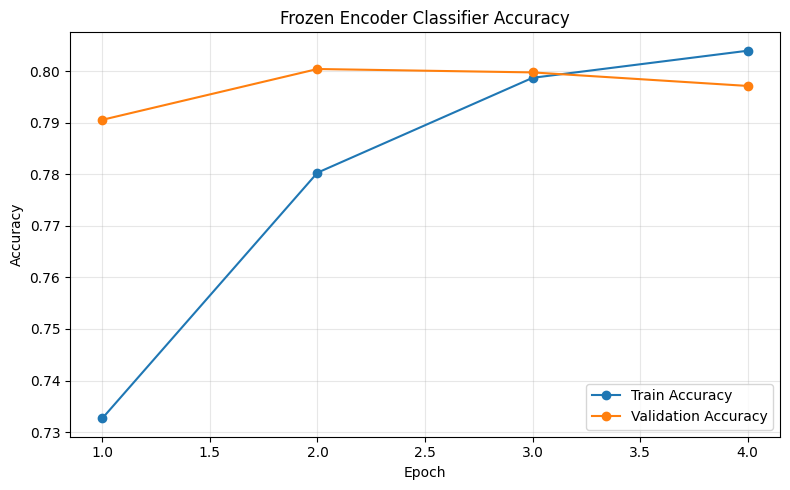

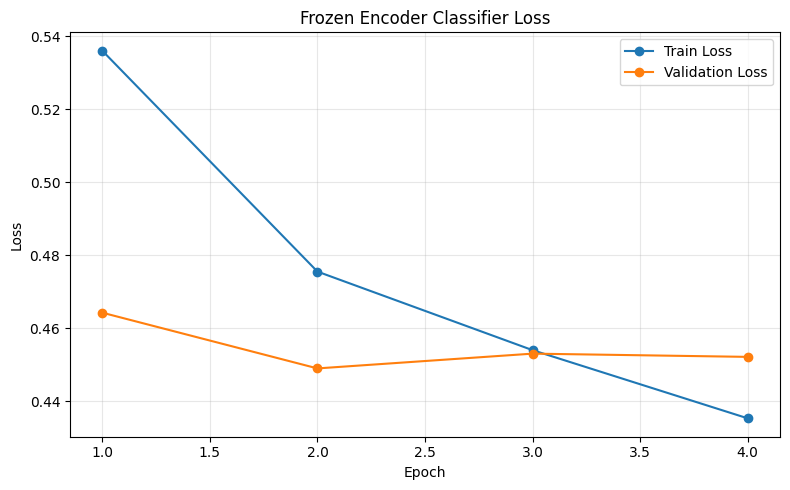

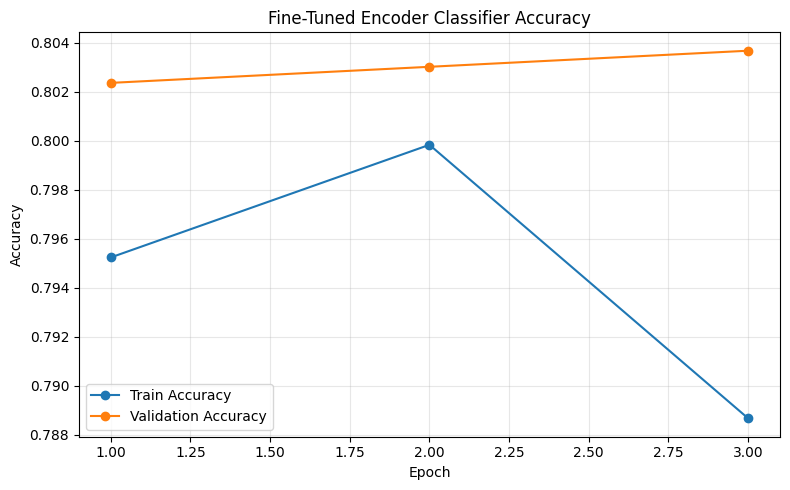

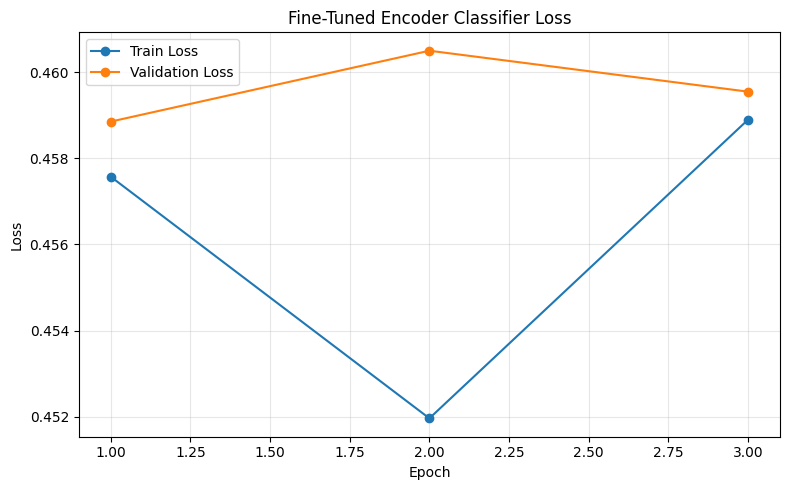

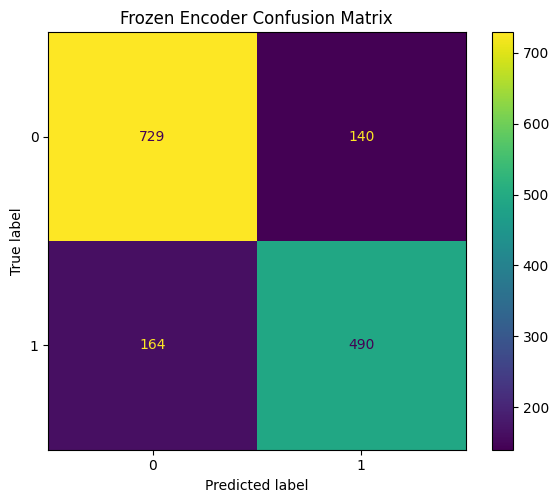

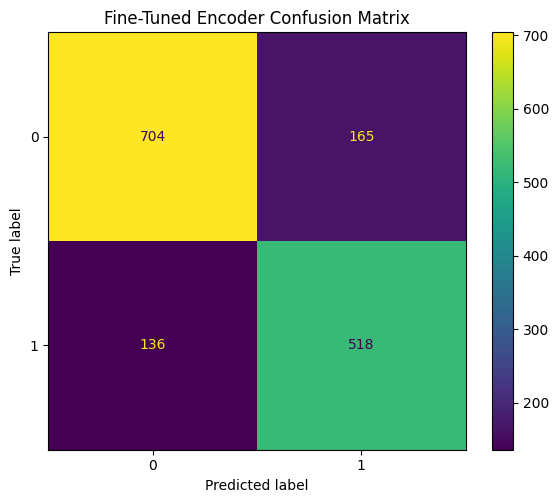

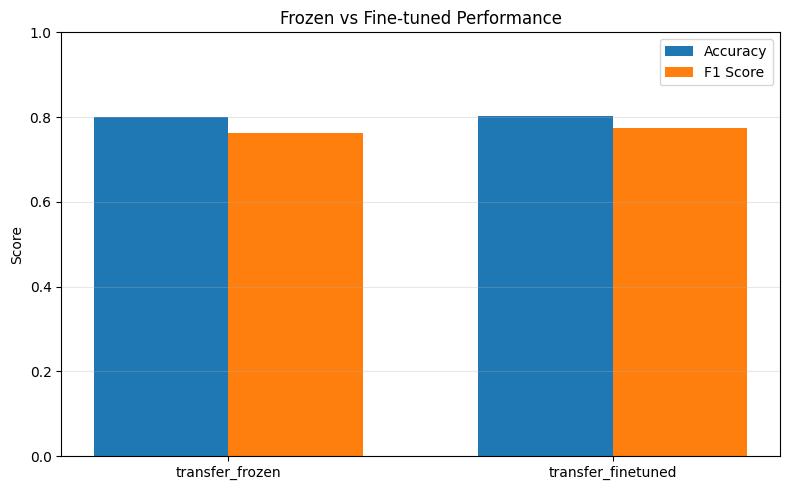

In [16]:

results = run(
    train_csv=train_csv,
    model_name=model_name,
    max_length=max_length,
    simcse_epochs=simcse_epochs,
    clf_epochs=clf_epochs,
    batch_size=batch_size,
    temperature=temperature,
    simcse_lr=simcse_lr,
    head_lr=head_lr,
    ft_lr=ft_lr,
    encoder_dir=encoder_dir,
    force_pretrain=force_pretrain
)
